# kimjaehak_013 · 비용을 제외한 모델 성능 비교

`kimjaehak_011`에서 유망했던 Expanding 재학습의 효과를 threshold와 비용 없이 다시 검증한다. 중복 제거, 10개 시간 window, `mapping.json` 기반 검사유형별 XGBoost를 유지하고 Fixed / Expanding / Rolling-6의 순위 및 확률 성능만 비교한다.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from xgboost import XGBClassifier

EXPERIMENT_ID = '0825_kimjaehak_013_cost_free_model_performance'
RANDOM_STATE = 42
DATA_PATH = Path('../data/raw/dataset.csv')
MAPPING_PATH = Path('../data/raw/mapping.json')
TARGET = 'class'
TIME_COLUMN = 'timestamp'
TYPE_COLUMN = 'inspection_type'
RECORD_ID = 'record_id'
ALL_WINDOWS = [f'W{number:02d}' for number in range(1, 11)]
WALK_FORWARD_PAIRS = [('W07', 'W08'), ('W08', 'W09'), ('W09', 'W10')]
MODEL_VARIANTS = ['fixed', 'expanding', 'rolling_6']
PROBABILITY_EPSILON = 1e-6

assert DATA_PATH.exists() and MAPPING_PATH.exists()
print('experiment:', EXPERIMENT_ID)
print('cost and threshold metrics: excluded')

experiment: 0825_kimjaehak_013_cost_free_model_performance
cost and threshold metrics: excluded


## 1. 전체 데이터 로드와 중복 제거

기존 baseline과 동일하게 `record_id`, `timestamp`를 제외한 컬럼이 같은 행은 첫 행만 남긴다. 같은 timestamp 그룹이 서로 다른 window로 갈라지지 않도록 시간순 10개 window를 만든다.

In [2]:
raw_df = pd.read_csv(DATA_PATH, low_memory=False)
source_index_column = raw_df.columns[0]
if source_index_column.startswith('Unnamed:'):
    raw_df = raw_df.rename(columns={source_index_column: RECORD_ID})
elif source_index_column != RECORD_ID:
    raise ValueError(f'예상하지 못한 첫 번째 컬럼: {source_index_column}')

dedup_columns = [column for column in raw_df.columns if column not in {RECORD_ID, TIME_COLUMN}]
duplicate_mask = raw_df.duplicated(subset=dedup_columns, keep='first')
clean_df = raw_df.loc[~duplicate_mask].copy().reset_index(drop=True)
clean_df[TIME_COLUMN] = pd.to_datetime(clean_df[TIME_COLUMN], errors='raise', utc=True)
clean_df = clean_df.sort_values([TIME_COLUMN, RECORD_ID], kind='stable').reset_index(drop=True)

timestamp_group_sizes = clean_df[TIME_COLUMN].value_counts(sort=False).sort_index()
cumulative_rows = timestamp_group_sizes.cumsum().to_numpy()

def boundary_time(fraction):
    position = int(np.searchsorted(cumulative_rows, len(clean_df) * fraction, side='left'))
    return timestamp_group_sizes.index[position]

window_end_times = pd.DatetimeIndex([boundary_time(fraction) for fraction in np.arange(0.1, 1.01, 0.1)])
window_number = np.searchsorted(
    window_end_times.astype('int64').to_numpy(),
    clean_df[TIME_COLUMN].astype('int64').to_numpy(),
    side='left',
)
clean_df['window'] = pd.Categorical(
    [f'W{number + 1:02d}' for number in window_number], categories=ALL_WINDOWS, ordered=True
)

window_data_summary = clean_df.groupby('window', observed=False).agg(
    rows=(TARGET, 'size'), positives=(TARGET, 'sum'), positive_rate=(TARGET, 'mean')
)
window_data_summary['positive_rate_pct'] = window_data_summary['positive_rate'] * 100
assert len(clean_df) == 391_992
assert clean_df.groupby(TIME_COLUMN)['window'].nunique().max() == 1
print(f'raw rows: {len(raw_df):,}, removed duplicates: {int(duplicate_mask.sum()):,}, clean rows: {len(clean_df):,}')
display(window_data_summary)

raw rows: 440,274, removed duplicates: 48,282, clean rows: 391,992


,rows,positives,positive_rate,positive_rate_pct
window,,,,
W01,39210,73,0.001862,0.186177
W02,39196,712,0.018165,1.816512
W03,39202,414,0.010561,1.056069
W04,39192,201,0.005129,0.512860
W05,39202,277,0.007066,0.706597
W06,39220,147,0.003748,0.374809
W07,39180,36,0.000919,0.091884
W08,39194,327,0.008343,0.834311
W09,39197,941,0.024007,2.400694


## 2. 비교 설계

- Fixed: 모든 평가 구간에서 W01~W06 학습
- Expanding: calibration 직전까지의 모든 window를 누적 학습
- Rolling-6: calibration 직전의 최근 6개 window만 학습

직전 window는 다음 비용 실험에서 threshold 선택에 사용될 수 있도록 학습에서 제외한다. W08에서는 세 정책 모두 W01~W06을 사용하므로 구현 일치성 점검 구간이고, W09~W10에서 재학습 효과가 갈린다.

In [3]:
inspection_types = sorted(clean_df[TYPE_COLUMN].unique().tolist())
with MAPPING_PATH.open(encoding='utf-8') as mapping_file:
    feature_mapping = json.load(mapping_file)
assert set(feature_mapping) == {str(value) for value in inspection_types}

meta_columns = [column for column in clean_df.columns if column.startswith('meta_feat')]
feature_columns_by_type = {
    inspection_type: meta_columns + feature_mapping[str(inspection_type)]
    for inspection_type in inspection_types
}

def training_windows_for(variant, calibration_window):
    calibration_position = ALL_WINDOWS.index(calibration_window)
    if variant == 'fixed':
        return ALL_WINDOWS[:6]
    if variant == 'expanding':
        return ALL_WINDOWS[:calibration_position]
    if variant == 'rolling_6':
        return ALL_WINDOWS[max(0, calibration_position - 6):calibration_position]
    raise ValueError(variant)

training_schedule = pd.DataFrame([
    {
        'calibration_window': calibration_window,
        'evaluation_window': evaluation_window,
        'variant': variant,
        'training_windows': '~'.join(training_windows_for(variant, calibration_window)),
    }
    for calibration_window, evaluation_window in WALK_FORWARD_PAIRS
    for variant in MODEL_VARIANTS
])
display(training_schedule)

,calibration_window,evaluation_window,variant,training_windows
0,W07,W08,fixed,W01~W02~W03~W04~W05~W06
1,W07,W08,expanding,W01~W02~W03~W04~W05~W06
2,W07,W08,rolling_6,W01~W02~W03~W04~W05~W06
3,W08,W09,fixed,W01~W02~W03~W04~W05~W06
4,W08,W09,expanding,W01~W02~W03~W04~W05~W06~W07
5,W08,W09,rolling_6,W02~W03~W04~W05~W06~W07
6,W09,W10,fixed,W01~W02~W03~W04~W05~W06
7,W09,W10,expanding,W01~W02~W03~W04~W05~W06~W07~W08
8,W09,W10,rolling_6,W03~W04~W05~W06~W07~W08


## 3. 모델 학습과 미래 구간 예측

모델 선택에 미래 구간을 사용하지 않는다. 같은 학습 window 조합은 캐시하며, 각 inspection type에는 해당 mapping 피처와 공통 meta 피처만 사용한다.

In [4]:
model_cache = {}
training_rows = []
prediction_frames = []

def fit_models(training_windows):
    cache_key = tuple(training_windows)
    if cache_key in model_cache:
        return model_cache[cache_key]
    models = {}
    for inspection_type in inspection_types:
        feature_columns = feature_columns_by_type[inspection_type]
        type_train = clean_df.loc[
            clean_df['window'].isin(training_windows)
            & (clean_df[TYPE_COLUMN] == inspection_type)
        ]
        model = XGBClassifier(
            random_state=RANDOM_STATE, n_jobs=-1, tree_method='hist',
            objective='binary:logistic', eval_metric=['logloss', 'aucpr'],
        )
        model.fit(type_train[feature_columns], type_train[TARGET].astype('int8'), verbose=False)
        models[inspection_type] = model
        training_rows.append({
            'training_windows': '~'.join(training_windows),
            'inspection_type': inspection_type,
            'train_rows': len(type_train),
            'train_positives': int(type_train[TARGET].sum()),
        })
    model_cache[cache_key] = models
    return models

for calibration_window, evaluation_window in WALK_FORWARD_PAIRS:
    for variant in MODEL_VARIANTS:
        training_windows = training_windows_for(variant, calibration_window)
        models = fit_models(training_windows)
        for inspection_type in inspection_types:
            evaluation_df = clean_df.loc[
                (clean_df['window'] == evaluation_window)
                & (clean_df[TYPE_COLUMN] == inspection_type)
            ]
            feature_columns = feature_columns_by_type[inspection_type]
            probabilities = models[inspection_type].predict_proba(evaluation_df[feature_columns])[:, 1]
            prediction_frames.append(pd.DataFrame({
                'evaluation_window': evaluation_window,
                'variant': variant,
                'inspection_type': inspection_type,
                'y_true': evaluation_df[TARGET].astype('int8').to_numpy(),
                'probability': probabilities,
            }))

training_history = pd.DataFrame(training_rows)
row_predictions = pd.concat(prediction_frames, ignore_index=True)
print('unique training configurations:', len(model_cache))
print('trained type models:', len(model_cache) * len(inspection_types))
display(training_history)

unique training configurations: 5
trained type models: 25


,training_windows,inspection_type,train_rows,train_positives
0,W01~W02~W03~W04~W05~W06,0,41961,57
1,W01~W02~W03~W04~W05~W06,1,34041,555
2,W01~W02~W03~W04~W05~W06,2,74910,579
3,W01~W02~W03~W04~W05~W06,3,80792,620
4,W01~W02~W03~W04~W05~W06,4,3518,13
5,W01~W02~W03~W04~W05~W06~W07,0,53298,58
6,W01~W02~W03~W04~W05~W06~W07,1,38521,580
7,W01~W02~W03~W04~W05~W06~W07,2,86269,586
8,W01~W02~W03~W04~W05~W06~W07,3,92495,623
9,W01~W02~W03~W04~W05~W06~W07,4,3819,13


## 4. 비용과 threshold가 없는 평가

주 지표는 각 type의 PR-AUC를 그 type의 실제 불량 수로 가중한 `positive_weighted_type_pr_auc`다. type별 모델의 raw score 척도가 다를 수 있어 pooled PR-AUC는 보조 지표로 둔다. ROC-AUC, Brier, log loss도 함께 확인한다.

In [5]:
def safe_average_precision(y_true, probabilities):
    return average_precision_score(y_true, probabilities) if len(np.unique(y_true)) > 1 else np.nan

def safe_roc_auc(y_true, probabilities):
    return roc_auc_score(y_true, probabilities) if len(np.unique(y_true)) > 1 else np.nan

def probability_metrics(y_true, probabilities):
    y_true = np.asarray(y_true, dtype='int8')
    probabilities = np.asarray(probabilities, dtype='float64')
    clipped = np.clip(probabilities, PROBABILITY_EPSILON, 1 - PROBABILITY_EPSILON)
    return {
        'rows': len(y_true),
        'positives': int(y_true.sum()),
        'positive_rate': y_true.mean(),
        'pr_auc': safe_average_precision(y_true, probabilities),
        'roc_auc': safe_roc_auc(y_true, probabilities),
        'brier': brier_score_loss(y_true, probabilities),
        'log_loss': log_loss(y_true, clipped, labels=[0, 1]),
    }

type_metric_rows = []
for keys, group in row_predictions.groupby(['evaluation_window', 'variant', 'inspection_type'], sort=False):
    type_metric_rows.append(dict(zip(['evaluation_window', 'variant', 'inspection_type'], keys)) | probability_metrics(group['y_true'], group['probability']))
type_metrics = pd.DataFrame(type_metric_rows)

def summarize_window(group):
    pooled = probability_metrics(group['y_true'], group['probability'])
    key = group.name
    per_type = type_metrics.loc[
        (type_metrics['evaluation_window'] == key[0]) & (type_metrics['variant'] == key[1])
    ].dropna(subset=['pr_auc'])
    pooled['macro_type_pr_auc'] = per_type['pr_auc'].mean()
    pooled['positive_weighted_type_pr_auc'] = np.average(per_type['pr_auc'], weights=per_type['positives'])
    pooled['row_weighted_type_pr_auc'] = np.average(per_type['pr_auc'], weights=per_type['rows'])
    return pd.Series(pooled)

window_model_summary = (
    row_predictions.groupby(['evaluation_window', 'variant'], sort=False)
    .apply(summarize_window, include_groups=False)
)
display(window_model_summary)
display(type_metrics[['evaluation_window', 'variant', 'inspection_type', 'positives', 'pr_auc', 'roc_auc']])

rows  positives  positive_rate    pr_auc  \
evaluation_window variant                                                  
W08               fixed      39194.0      327.0       0.008343  0.278423   
                  expanding  39194.0      327.0       0.008343  0.278423   
                  rolling_6  39194.0      327.0       0.008343  0.278423   
W09               fixed      39197.0      941.0       0.024007  0.314224   
                  expanding  39197.0      941.0       0.024007  0.303211   
                  rolling_6  39197.0      941.0       0.024007  0.328431   
W10               fixed      39199.0     1308.0       0.033368  0.353813   
                  expanding  39199.0     1308.0       0.033368  0.503099   
                  rolling_6  39199.0     1308.0       0.033368  0.429903   

                              roc_auc     brier  log_loss  macro_type_pr_auc  \
evaluation_window variant                                                      
W08               fixed      0.900285  0.009770  0.048659           0.190792   
                  expanding  0.900285  0.009770  0.048659           0.190792   
                  rolling_6  0.900285  0.009770  0.048659           0.190792   
W09               fixed      0.920263  0.022200  0.114493           0.271993   
                  expanding  0.920791  0.023964  0.115340           0.300880   
                  rolling_6  0.911496  0.021941  0.115323           0.302650   
W10               fixed      0.832543  0.029695  0.157546           0.220656   
                  expanding  0.877270  0.022332  0.137638           0.301814   
                  rolling_6  0.843231  0.024663  0.163846           0.244156   

                             positive_weighted_type_pr_auc  \
evaluation_window variant                                    
W08               fixed                           0.458541   
                  expanding                       0.458541   
                  rolling_6                       0.458541   
W09               fixed                           0.388373   
                  expanding                       0.451414   
                  rolling_6                       0.439031   
W10               fixed                           0.366676   
                  expanding                       0.507455   
                  rolling_6                       0.438885   

                             row_weighted_type_pr_auc  
evaluation_window variant                              
W08               fixed                      0.174498  
                  expanding                  0.174498  
                  rolling_6                  0.174498  
W09               fixed                      0.323951  
                  expanding                  0.384939  
                  rolling_6                  0.372764  
W10               fixed                      0.257852  
                  expanding                  0.325546  
                  rolling_6                  0.258849

,evaluation_window,variant,inspection_type,positives,pr_auc,roc_auc
0,W08,fixed,0,7,0.008086,0.865892
1,W08,fixed,1,214,0.658596,0.947697
2,W08,fixed,2,25,0.063254,0.776787
3,W08,fixed,3,21,0.155799,0.919880
4,W08,fixed,4,60,0.068228,0.377525
5,W08,expanding,0,7,0.008086,0.865892
6,W08,expanding,1,214,0.658596,0.947697
7,W08,expanding,2,25,0.063254,0.776787
8,W08,expanding,3,21,0.155799,0.919880
9,W08,expanding,4,60,0.068228,0.377525


In [6]:
variant_summary = window_model_summary.groupby('variant').agg(
    mean_positive_weighted_type_pr_auc=('positive_weighted_type_pr_auc', 'mean'),
    median_positive_weighted_type_pr_auc=('positive_weighted_type_pr_auc', 'median'),
    mean_macro_type_pr_auc=('macro_type_pr_auc', 'mean'),
    mean_pooled_pr_auc=('pr_auc', 'mean'),
    mean_roc_auc=('roc_auc', 'mean'),
    mean_brier=('brier', 'mean'),
    mean_log_loss=('log_loss', 'mean'),
).sort_values('mean_positive_weighted_type_pr_auc', ascending=False)
aggregate_rank_summary = pd.DataFrame([
    {'variant': variant, **probability_metrics(group['y_true'], group['probability'])}
    for variant, group in row_predictions.groupby('variant', sort=False)
]).set_index('variant')
variant_summary['aggregate_pooled_pr_auc'] = aggregate_rank_summary['pr_auc']
variant_summary['aggregate_brier'] = aggregate_rank_summary['brier']
variant_summary['aggregate_log_loss'] = aggregate_rank_summary['log_loss']

comparison_windows = ['W08', 'W09', 'W10']
fixed_scores = window_model_summary.xs('fixed', level='variant')['positive_weighted_type_pr_auc']
win_counts = {}
for variant in MODEL_VARIANTS:
    scores = window_model_summary.xs(variant, level='variant')['positive_weighted_type_pr_auc']
    win_counts[variant] = int((scores.loc[comparison_windows] > fixed_scores.loc[comparison_windows]).sum())
variant_summary['wins_vs_fixed_W08_W10'] = pd.Series(win_counts)
selected_variant = variant_summary.index[0]

# W08은 동일한 W01~W06 모델이므로 모든 확률이 같아야 한다.
w08 = row_predictions.loc[row_predictions['evaluation_window'] == 'W08']
w08_pivot = w08.pivot_table(index=['inspection_type', 'y_true'], columns='variant', values='probability', aggfunc=list)
assert all(np.allclose(row['fixed'], row['expanding']) and np.allclose(row['fixed'], row['rolling_6']) for _, row in w08_pivot.iterrows())

display(variant_summary)
print('cost-free selected variant:', selected_variant)

,mean_positive_weighted_type_pr_auc,median_positive_weighted_type_pr_auc,mean_macro_type_pr_auc,mean_pooled_pr_auc,mean_roc_auc,mean_brier,mean_log_loss,aggregate_pooled_pr_auc,aggregate_brier,aggregate_log_loss,wins_vs_fixed_W08_W10
variant,,,,,,,,,,,
expanding,0.472470,0.458541,0.264495,0.361578,0.899449,0.018689,0.100546,0.344535,0.018689,0.100548,2
rolling_6,0.445486,0.439031,0.245866,0.345586,0.885004,0.018791,0.109276,0.320067,0.018792,0.109278,2
fixed,0.404530,0.388373,0.227814,0.315486,0.884364,0.020555,0.106899,0.298083,0.020556,0.106902,0


cost-free selected variant: expanding


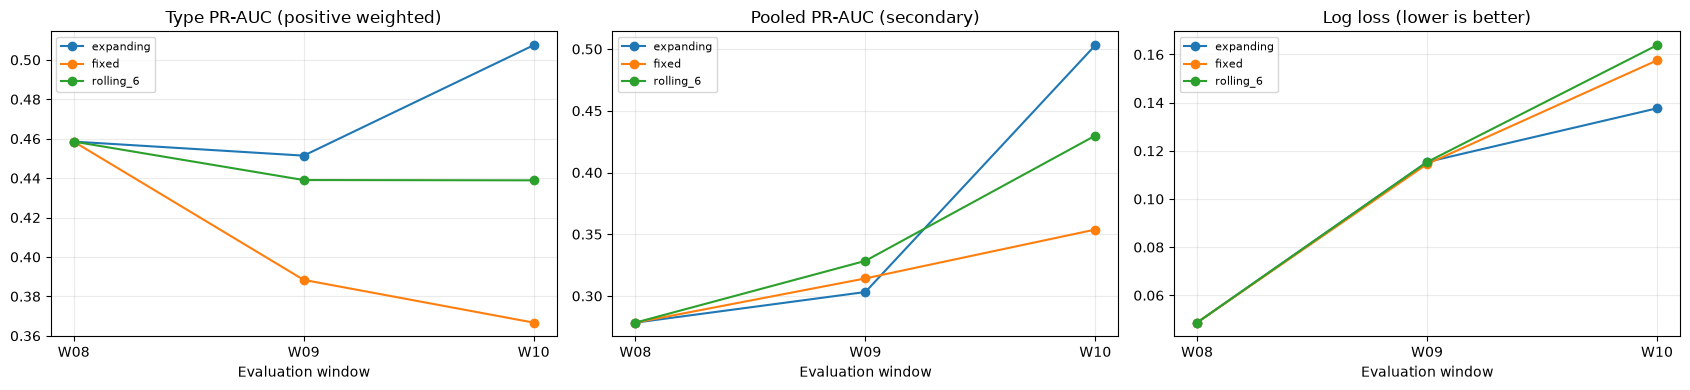

In [7]:
plot_df = window_model_summary.reset_index()
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for variant, group in plot_df.groupby('variant'):
    axes[0].plot(group['evaluation_window'], group['positive_weighted_type_pr_auc'], marker='o', label=variant)
    axes[1].plot(group['evaluation_window'], group['pr_auc'], marker='o', label=variant)
    axes[2].plot(group['evaluation_window'], group['log_loss'], marker='o', label=variant)
axes[0].set_title('Type PR-AUC (positive weighted)')
axes[1].set_title('Pooled PR-AUC (secondary)')
axes[2].set_title('Log loss (lower is better)')
for ax in axes:
    ax.set_xlabel('Evaluation window')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [8]:
fixed = variant_summary.loc['fixed']
selected = variant_summary.loc[selected_variant]
delta = selected['mean_positive_weighted_type_pr_auc'] - fixed['mean_positive_weighted_type_pr_auc']
conclusion = f'''
### 실행 결과

비용과 threshold를 사용하지 않은 주 지표에서 **{selected_variant}**가 선택되었습니다.

- Fixed 평균 positive-weighted type PR-AUC: **{fixed['mean_positive_weighted_type_pr_auc']:.6f}**
- {selected_variant} 평균 positive-weighted type PR-AUC: **{selected['mean_positive_weighted_type_pr_auc']:.6f}**
- Fixed 대비 차이: **{delta:+.6f}**
- W08~W10에서 Fixed를 이긴 구간: **{int(selected['wins_vs_fixed_W08_W10'])}/3**
- {selected_variant} W08~W10 aggregate pooled PR-AUC: **{selected['aggregate_pooled_pr_auc']:.6f}**
- {selected_variant} 평균 log loss: **{selected['mean_log_loss']:.6f}**

### 해석

이 판정은 재검사 비용이나 특정 threshold의 도움 없이 모델이 실제 불량을 위쪽에 더 잘 정렬하는지만 본 결과입니다. 다음 `kimjaehak_014`에서는 이 모델 후보를 고정하고, 직전 window에서 비용비율별 의사결정 threshold를 선택해 실제 FP·FN 비용이 줄어드는지 별도로 검증합니다.
'''
display(Markdown(conclusion))


### 실행 결과

비용과 threshold를 사용하지 않은 주 지표에서 **expanding**가 선택되었습니다.

- Fixed 평균 positive-weighted type PR-AUC: **0.404530**
- expanding 평균 positive-weighted type PR-AUC: **0.472470**
- Fixed 대비 차이: **+0.067940**
- W08~W10에서 Fixed를 이긴 구간: **2/3**
- expanding W08~W10 aggregate pooled PR-AUC: **0.344535**
- expanding 평균 log loss: **0.100546**

### 해석

이 판정은 재검사 비용이나 특정 threshold의 도움 없이 모델이 실제 불량을 위쪽에 더 잘 정렬하는지만 본 결과입니다. 다음 `kimjaehak_014`에서는 이 모델 후보를 고정하고, 직전 window에서 비용비율별 의사결정 threshold를 선택해 실제 FP·FN 비용이 줄어드는지 별도로 검증합니다.
